# EDA — Final Modeling Dataset (Pre-Modeling Checklist)

This notebook is a **pre-modeling sanity check** on the final feature-engineered dataset.  
The goal is to confirm the dataset is model-ready and to surface any issues (class imbalance, scale differences, collinearity, redundant features) before training.

**Dataset:** `modeling_dataset.csv`  
**Rows:** 211,800 | **Columns:** 35 (all numeric, zero missing values)

**Model Targets:**
- **Stage 1 — Classification:** `1MINCHANGE_FLAG_` — did the ETA change by ≥1 min? (binary)
- **Stage 2 — Classification:** `CHANGE_FLAG_10MIN` — did the ETA change by ≥10 min? (binary)
- **Regression targets:** `LEG_DEP_VARNCE_MIN_QTY`, `LEG_ARVL_VARNCE_MIN_QTY`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
})
BLUE   = '#1F77B4'
ORANGE = '#FF7F0E'
RED    = '#D62728'
GREEN  = '#2CA02C'

df = pd.read_csv('modeling_dataset.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()} (none — dataset is fully clean)')

Shape: 211,800 rows × 35 columns
Missing values: 0 (none — dataset is fully clean)


---
## 1. Class Imbalance Analysis — CRITICAL

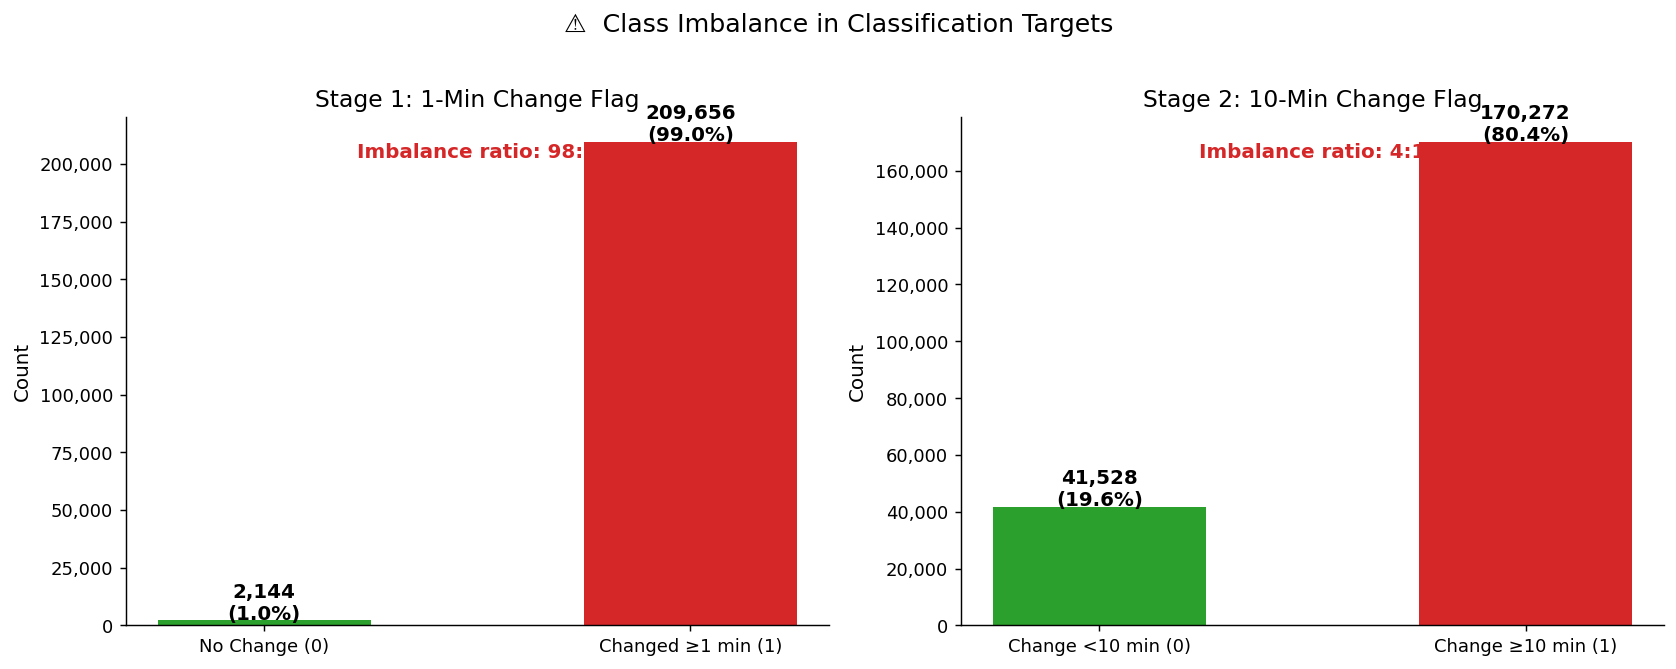


Stage 1 Summary:
  Class 0 (no change)  :   2,144  (1.01%)
  Class 1 (≥1 min chg) : 209,656  (98.99%)
  Imbalance ratio      : 98:1  → SMOTE / class_weight required

Stage 2 Summary:
  Class 0 (<10 min chg):  41,528  (19.61%)
  Class 1 (≥10 min chg): 170,272  (80.39%)
  Imbalance ratio      : 4.1:1  → class_weight recommended


In [2]:
# ── Stage 1 & Stage 2 target balance ────────────────────────────────────────
stage1 = df['1MINCHANGE_FLAG_'].value_counts()
stage2 = df['CHANGE_FLAG_10MIN'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, target, title, labels in zip(
    axes,
    [stage1, stage2],
    ['Stage 1: 1-Min Change Flag', 'Stage 2: 10-Min Change Flag'],
    [['No Change (0)', 'Changed ≥1 min (1)'], ['Change <10 min (0)', 'Change ≥10 min (1)']]
):
    colors = [GREEN, RED]
    bars = ax.bar(labels, target.sort_index().values, color=colors, width=0.5)
    for bar, val in zip(bars, target.sort_index().values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ratio = target.sort_index().values[1] / max(target.sort_index().values[0], 1)
    ax.text(0.5, 0.92, f'Imbalance ratio: {ratio:.0f}:1', transform=ax.transAxes,
            ha='center', fontsize=11, color=RED, fontweight='bold')

plt.suptitle('⚠️  Class Imbalance in Classification Targets', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_mod_class_balance.png', bbox_inches='tight')
plt.show()

print('\nStage 1 Summary:')
print(f'  Class 0 (no change)  : {stage1[0]:>7,}  ({stage1[0]/len(df)*100:.2f}%)')
print(f'  Class 1 (≥1 min chg) : {stage1[1]:>7,}  ({stage1[1]/len(df)*100:.2f}%)')
print(f'  Imbalance ratio      : {stage1[1]/stage1[0]:.0f}:1  → SMOTE / class_weight required')
print('\nStage 2 Summary:')
print(f'  Class 0 (<10 min chg): {stage2[0]:>7,}  ({stage2[0]/len(df)*100:.2f}%)')
print(f'  Class 1 (≥10 min chg): {stage2[1]:>7,}  ({stage2[1]/len(df)*100:.2f}%)')
print(f'  Imbalance ratio      : {stage2[1]/stage2[0]:.1f}:1  → class_weight recommended')

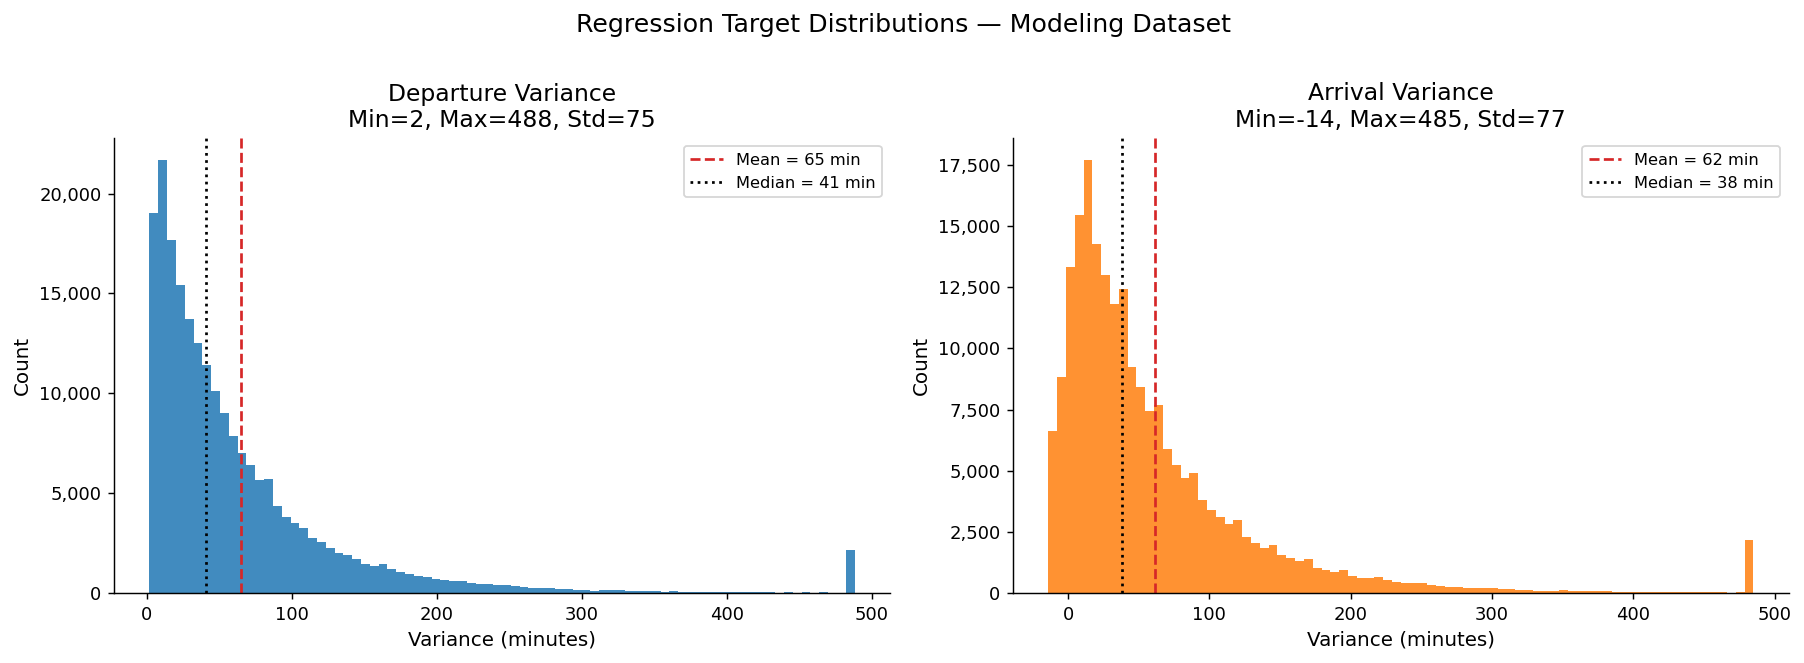

LEG_DEP_VARNCE_MIN_QTY:  skew=2.94,  kurtosis=11.42
LEG_ARVL_VARNCE_MIN_QTY:  skew=2.75,  kurtosis=10.16


In [3]:
# ── Regression targets (only on final filtered rows) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color in zip(
    axes,
    ['LEG_DEP_VARNCE_MIN_QTY', 'LEG_ARVL_VARNCE_MIN_QTY'],
    ['Departure Variance', 'Arrival Variance'],
    [BLUE, ORANGE]
):
    ax.hist(df[col], bins=80, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df[col].mean(),   color=RED,   linestyle='--', lw=1.5, label=f'Mean = {df[col].mean():.0f} min')
    ax.axvline(df[col].median(), color='black', linestyle=':', lw=1.5, label=f'Median = {df[col].median():.0f} min')
    ax.set_xlabel('Variance (minutes)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\nMin={df[col].min():.0f}, Max={df[col].max():.0f}, Std={df[col].std():.0f}')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Regression Target Distributions — Modeling Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_mod_reg_targets.png', bbox_inches='tight')
plt.show()

# Skewness
from scipy.stats import skew, kurtosis
for col in ['LEG_DEP_VARNCE_MIN_QTY', 'LEG_ARVL_VARNCE_MIN_QTY']:
    print(f'{col}:  skew={skew(df[col]):.2f},  kurtosis={kurtosis(df[col]):.2f}')

---
## 2. Feature Scale Analysis (Critical for Distance-Based Models)

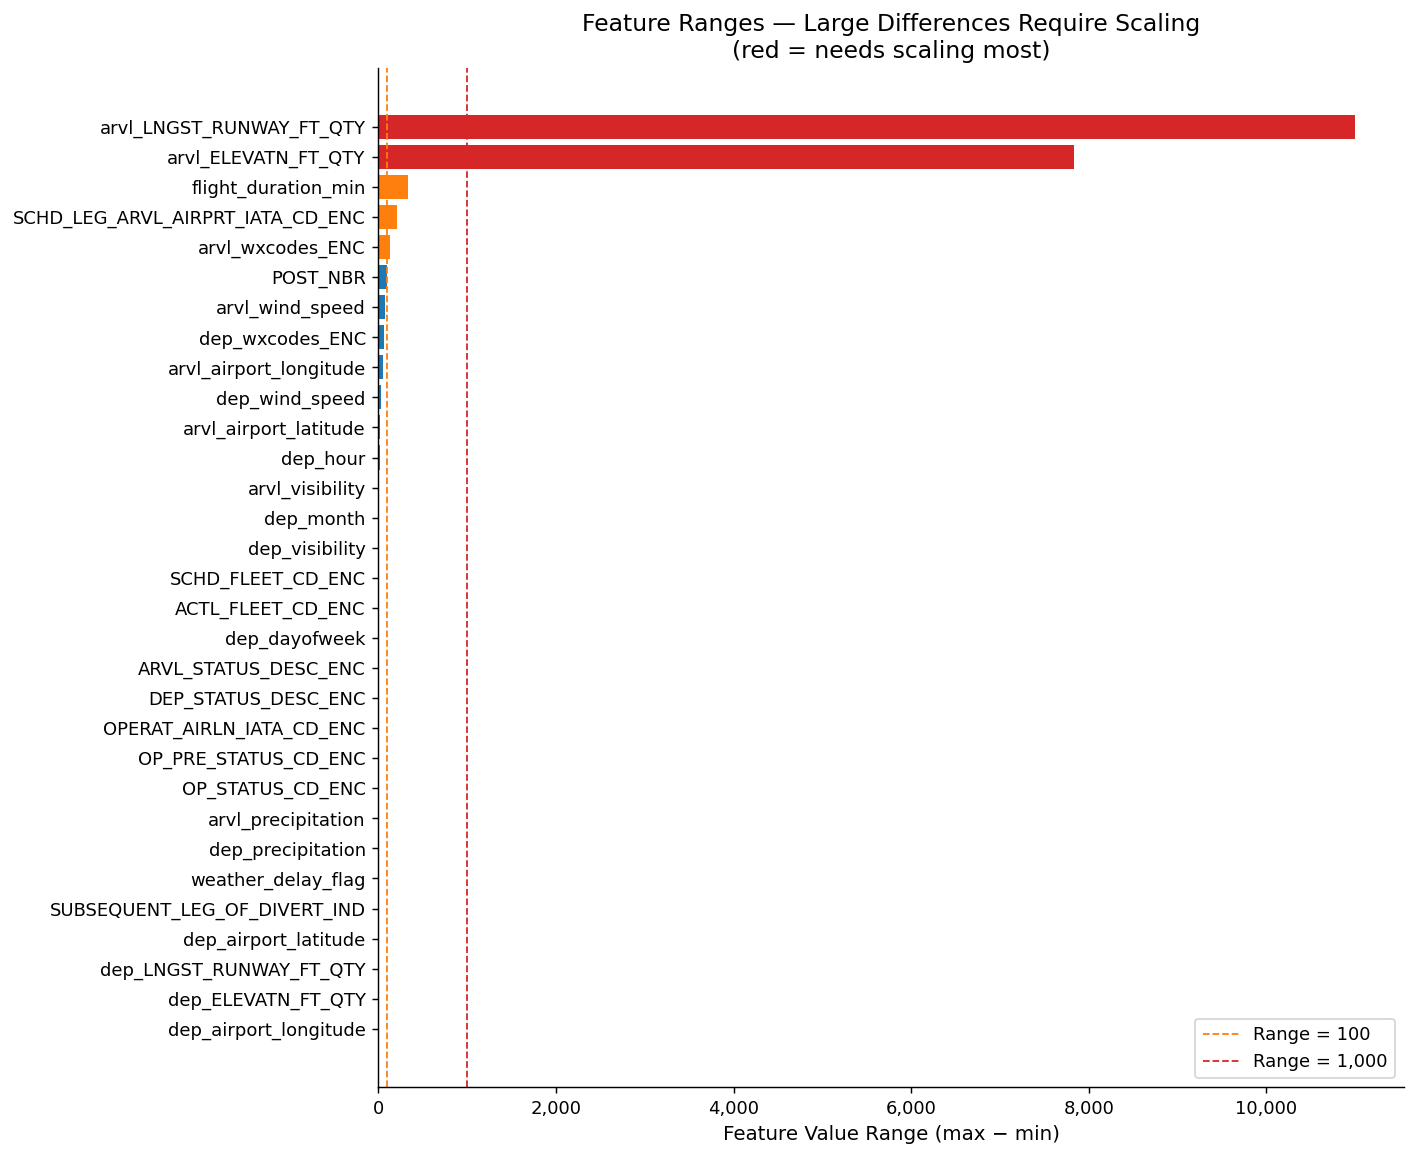

,min,max,range,mean,std
arvl_LNGST_RUNWAY_FT_QTY,5000.00,16000.00,11000.00,10217.05,2062.49
arvl_ELEVATN_FT_QTY,3.00,7838.00,7835.00,1066.81,1506.82
flight_duration_min,3.00,337.00,334.00,129.19,66.51
SCHD_LEG_ARVL_AIRPRT_IATA_CD_ENC,0.00,210.00,210.00,110.74,60.40
arvl_wxcodes_ENC,0.00,135.00,135.00,88.65,17.11
POST_NBR,1.00,97.00,96.00,4.83,3.35
arvl_wind_speed,0.00,70.00,70.00,7.53,4.49
dep_wxcodes_ENC,0.00,58.00,58.00,41.68,7.76
arvl_airport_longitude,-123.21,-68.83,54.38,-95.36,13.78
dep_wind_speed,0.00,32.00,32.00,9.43,4.62


In [4]:
# ── Feature ranges — shows which features need scaling ───────────────────────
feature_cols = [c for c in df.columns if c not in
                ['LEG_DEP_VARNCE_MIN_QTY','LEG_ARVL_VARNCE_MIN_QTY',
                 '1MINCHANGE_FLAG_','CHANGE_FLAG_10MIN']]

scale_df = df[feature_cols].agg(['min','max','mean','std']).T.round(2)
scale_df['range'] = scale_df['max'] - scale_df['min']
scale_df = scale_df.sort_values('range', ascending=False)

fig, ax = plt.subplots(figsize=(11, 9))
colors_scale = [RED if v > 1000 else ORANGE if v > 100 else BLUE for v in scale_df['range']]
ax.barh(scale_df.index[::-1], scale_df['range'][::-1], color=colors_scale[::-1])
ax.axvline(100,  color=ORANGE, linestyle='--', lw=1, label='Range = 100')
ax.axvline(1000, color=RED,    linestyle='--', lw=1, label='Range = 1,000')
ax.set_xlabel('Feature Value Range (max − min)')
ax.set_title('Feature Ranges — Large Differences Require Scaling\n(red = needs scaling most)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('eda_mod_feature_ranges.png', bbox_inches='tight')
plt.show()

display(scale_df[['min','max','range','mean','std']])

---
## 3. Feature Distributions

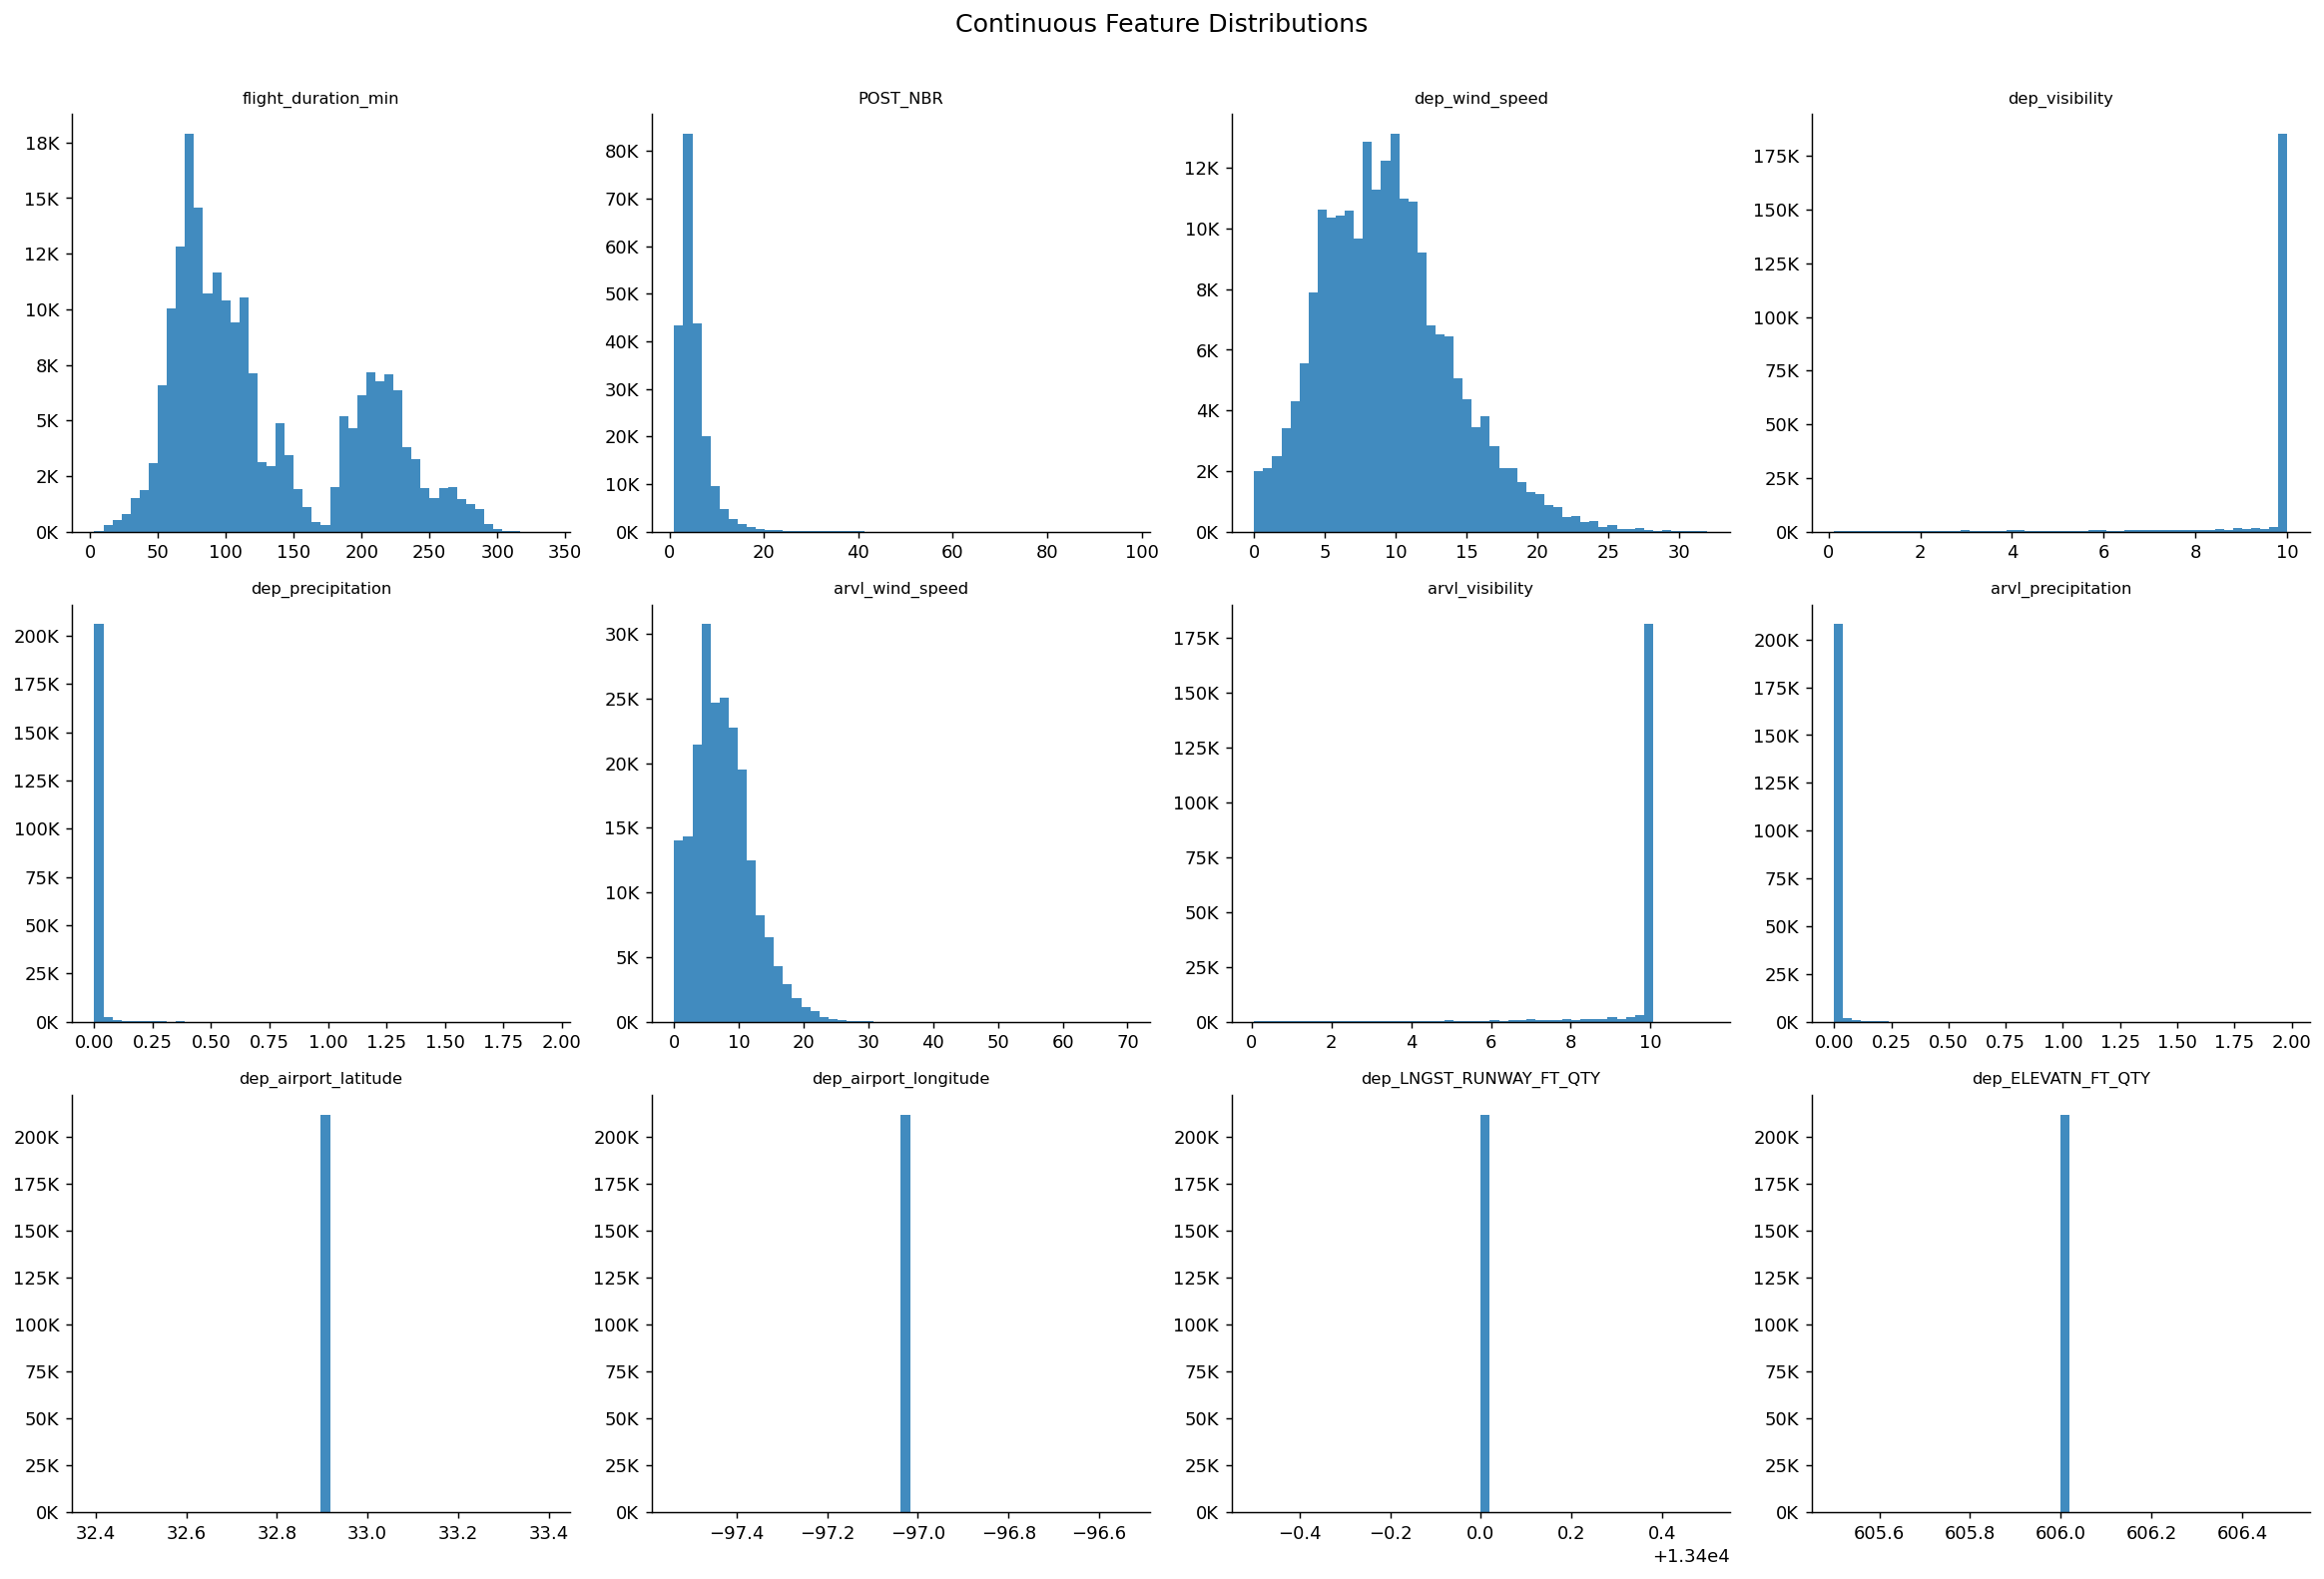

In [5]:
# ── Continuous feature distributions ─────────────────────────────────────────
continuous = ['flight_duration_min', 'POST_NBR', 'dep_wind_speed', 'dep_visibility',
              'dep_precipitation', 'arvl_wind_speed', 'arvl_visibility', 'arvl_precipitation',
              'dep_airport_latitude', 'dep_airport_longitude',
              'dep_LNGST_RUNWAY_FT_QTY', 'dep_ELEVATN_FT_QTY']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for ax, col in zip(axes.flatten(), continuous):
    ax.hist(df[col], bins=50, color=BLUE, edgecolor='none', alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Continuous Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_mod_cont_distributions.png', bbox_inches='tight')
plt.show()

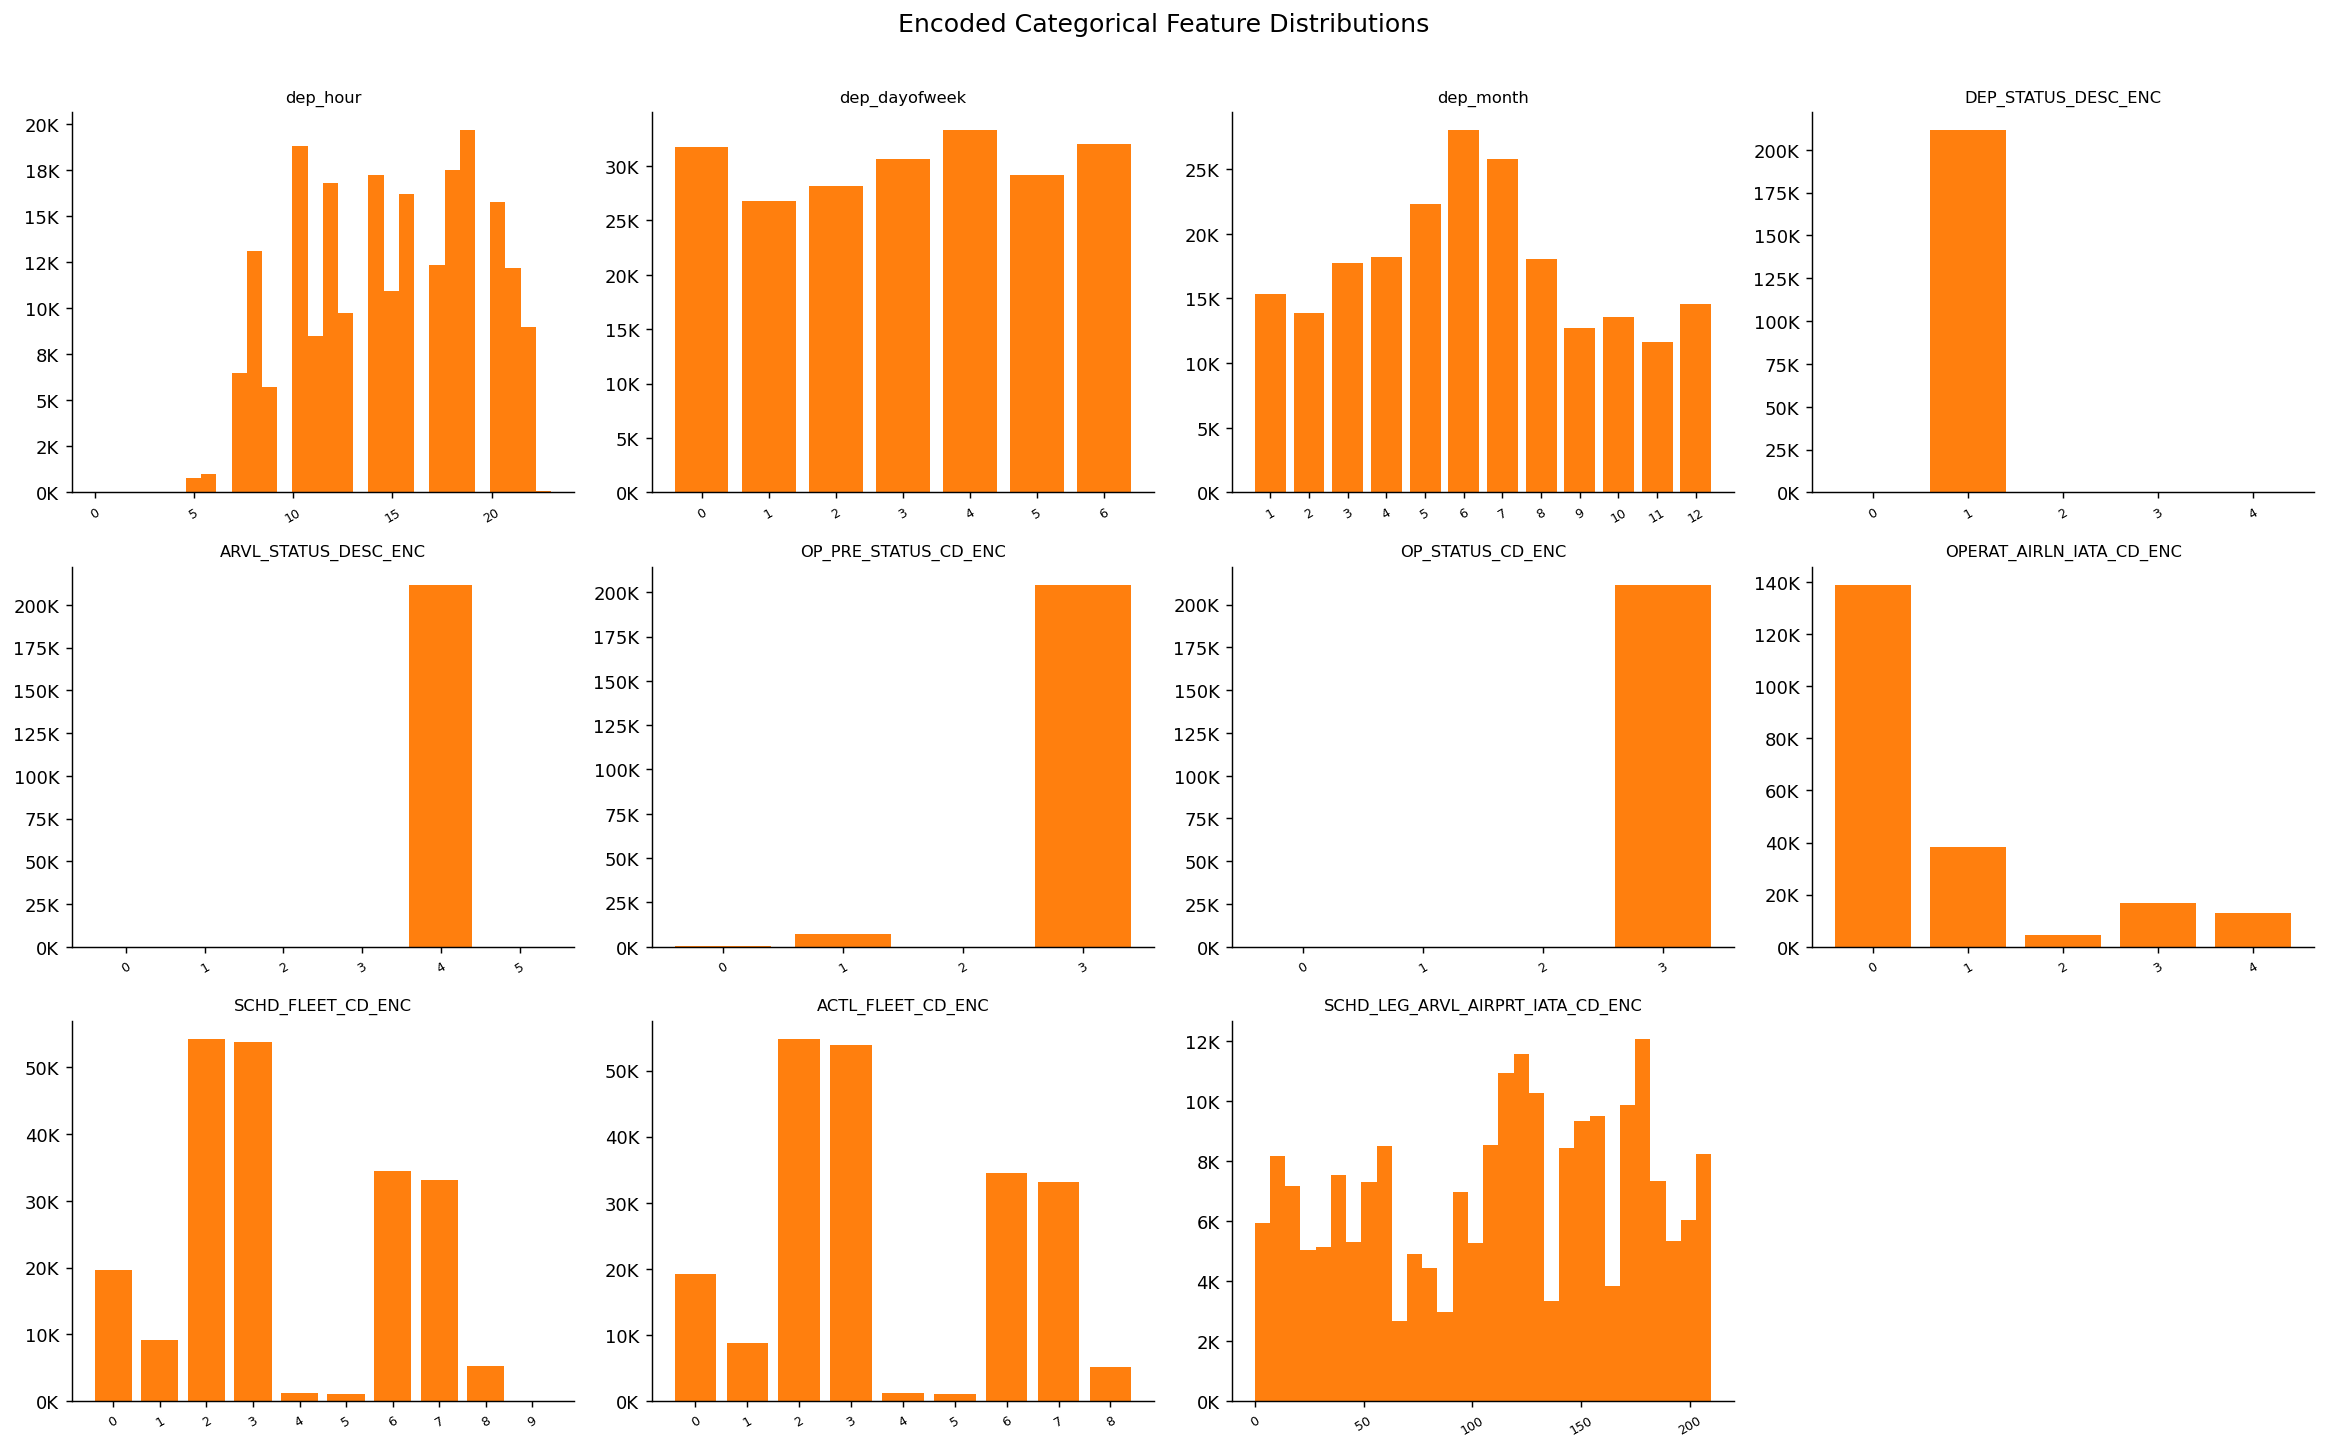

In [6]:
# ── Categorical (encoded) feature distributions ──────────────────────────────
encoded_cats = ['dep_hour','dep_dayofweek','dep_month',
                'DEP_STATUS_DESC_ENC','ARVL_STATUS_DESC_ENC',
                'OP_PRE_STATUS_CD_ENC','OP_STATUS_CD_ENC',
                'OPERAT_AIRLN_IATA_CD_ENC','SCHD_FLEET_CD_ENC',
                'ACTL_FLEET_CD_ENC','SCHD_LEG_ARVL_AIRPRT_IATA_CD_ENC']

fig, axes = plt.subplots(3, 4, figsize=(18, 11))

for ax, col in zip(axes.flatten(), encoded_cats):
    vc = df[col].value_counts().sort_index()
    if len(vc) <= 20:
        ax.bar(vc.index.astype(str), vc.values, color=ORANGE)
    else:
        ax.hist(df[col], bins=30, color=ORANGE, edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Hide the empty last subplot
axes.flatten()[-1].set_visible(False)

plt.suptitle('Encoded Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_mod_cat_distributions.png', bbox_inches='tight')
plt.show()

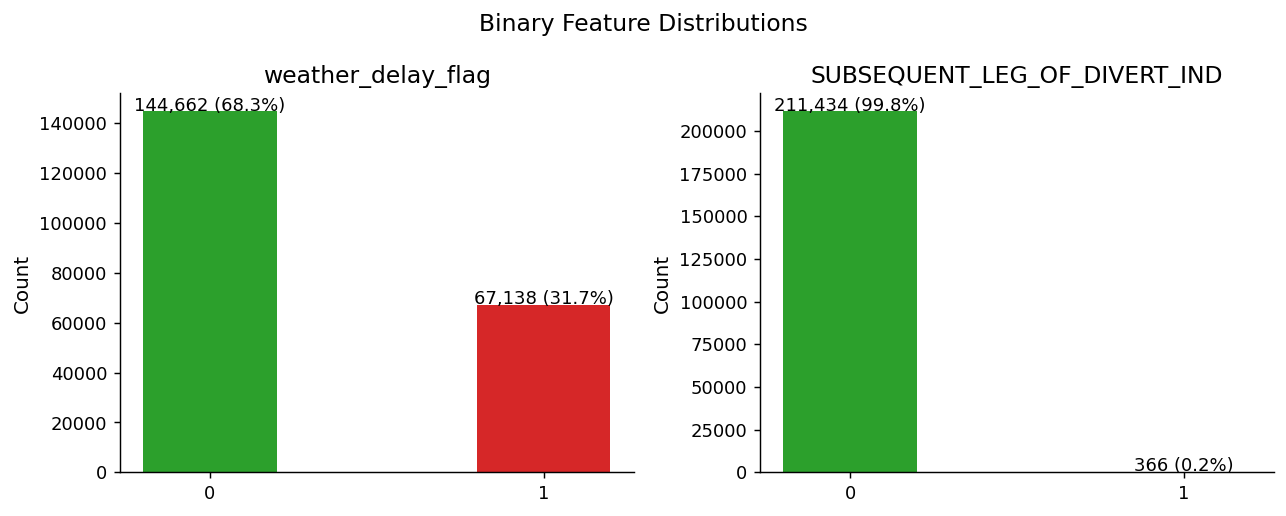

In [7]:
# ── Binary flags ─────────────────────────────────────────────────────────────
binary_cols = ['weather_delay_flag', 'SUBSEQUENT_LEG_OF_DIVERT_IND']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, binary_cols):
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(['0', '1'], vc.values, color=[GREEN, RED], width=0.4)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,} ({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.suptitle('Binary Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('eda_mod_binary_flags.png', bbox_inches='tight')
plt.show()

---
## 4. Feature-Target Correlation

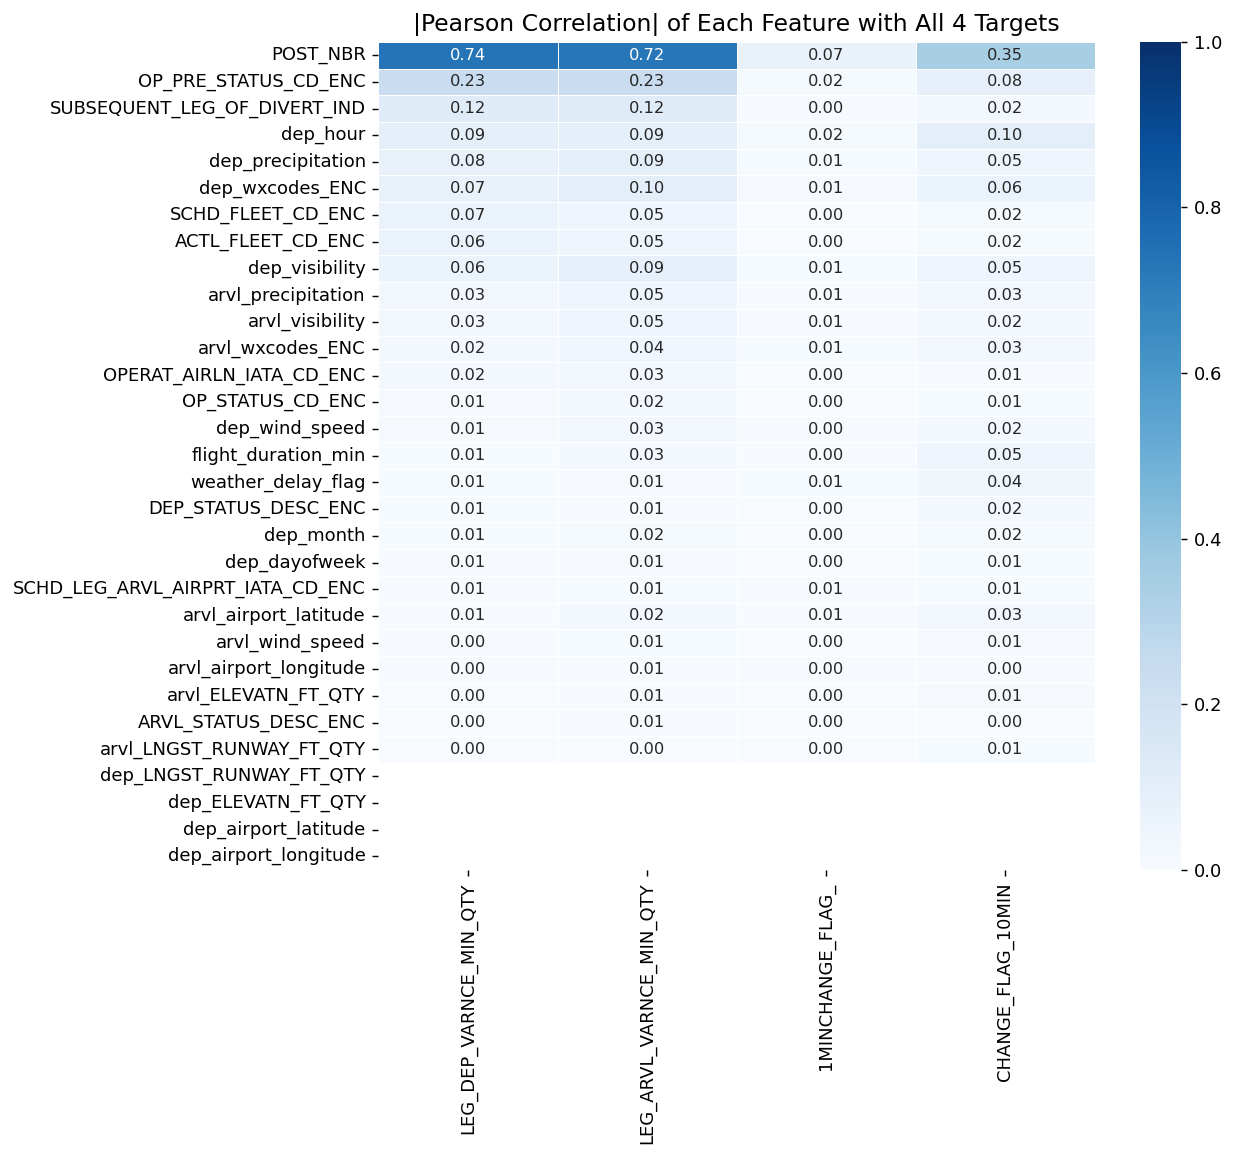

In [8]:
# ── Correlation with all 4 targets ───────────────────────────────────────────
targets = ['LEG_DEP_VARNCE_MIN_QTY','LEG_ARVL_VARNCE_MIN_QTY',
           '1MINCHANGE_FLAG_','CHANGE_FLAG_10MIN']

corr_all = df.corr()[targets].drop(targets).abs().sort_values('LEG_DEP_VARNCE_MIN_QTY', ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    corr_all, annot=True, fmt='.2f',
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('|Pearson Correlation| of Each Feature with All 4 Targets', fontsize=13)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('eda_mod_feature_target_corr.png', bbox_inches='tight')
plt.show()

In [9]:
# ── Top 10 features by correlation with each target ──────────────────────────
print('Top 10 features correlated with each target:\n')
for t in targets:
    top10 = df.corr()[t].drop(targets).abs().sort_values(ascending=False).head(10)
    print(f'--- {t} ---')
    for feat, val in top10.items():
        print(f'  {feat:<40} {val:.4f}')
    print()

Top 10 features correlated with each target:

--- LEG_DEP_VARNCE_MIN_QTY ---
  POST_NBR                                 0.7357
  OP_PRE_STATUS_CD_ENC                     0.2333
  SUBSEQUENT_LEG_OF_DIVERT_IND             0.1225
  dep_hour                                 0.0901
  dep_precipitation                        0.0755
  dep_wxcodes_ENC                          0.0739
  SCHD_FLEET_CD_ENC                        0.0659
  ACTL_FLEET_CD_ENC                        0.0643
  dep_visibility                           0.0587
  arvl_precipitation                       0.0344

--- LEG_ARVL_VARNCE_MIN_QTY ---
  POST_NBR                                 0.7229
  OP_PRE_STATUS_CD_ENC                     0.2311
  SUBSEQUENT_LEG_OF_DIVERT_IND             0.1192
  dep_wxcodes_ENC                          0.1030
  dep_precipitation                        0.0942
  dep_hour                                 0.0922
  dep_visibility                           0.0855
  SCHD_FLEET_CD_ENC                     

---
## 5. Multicollinearity Check

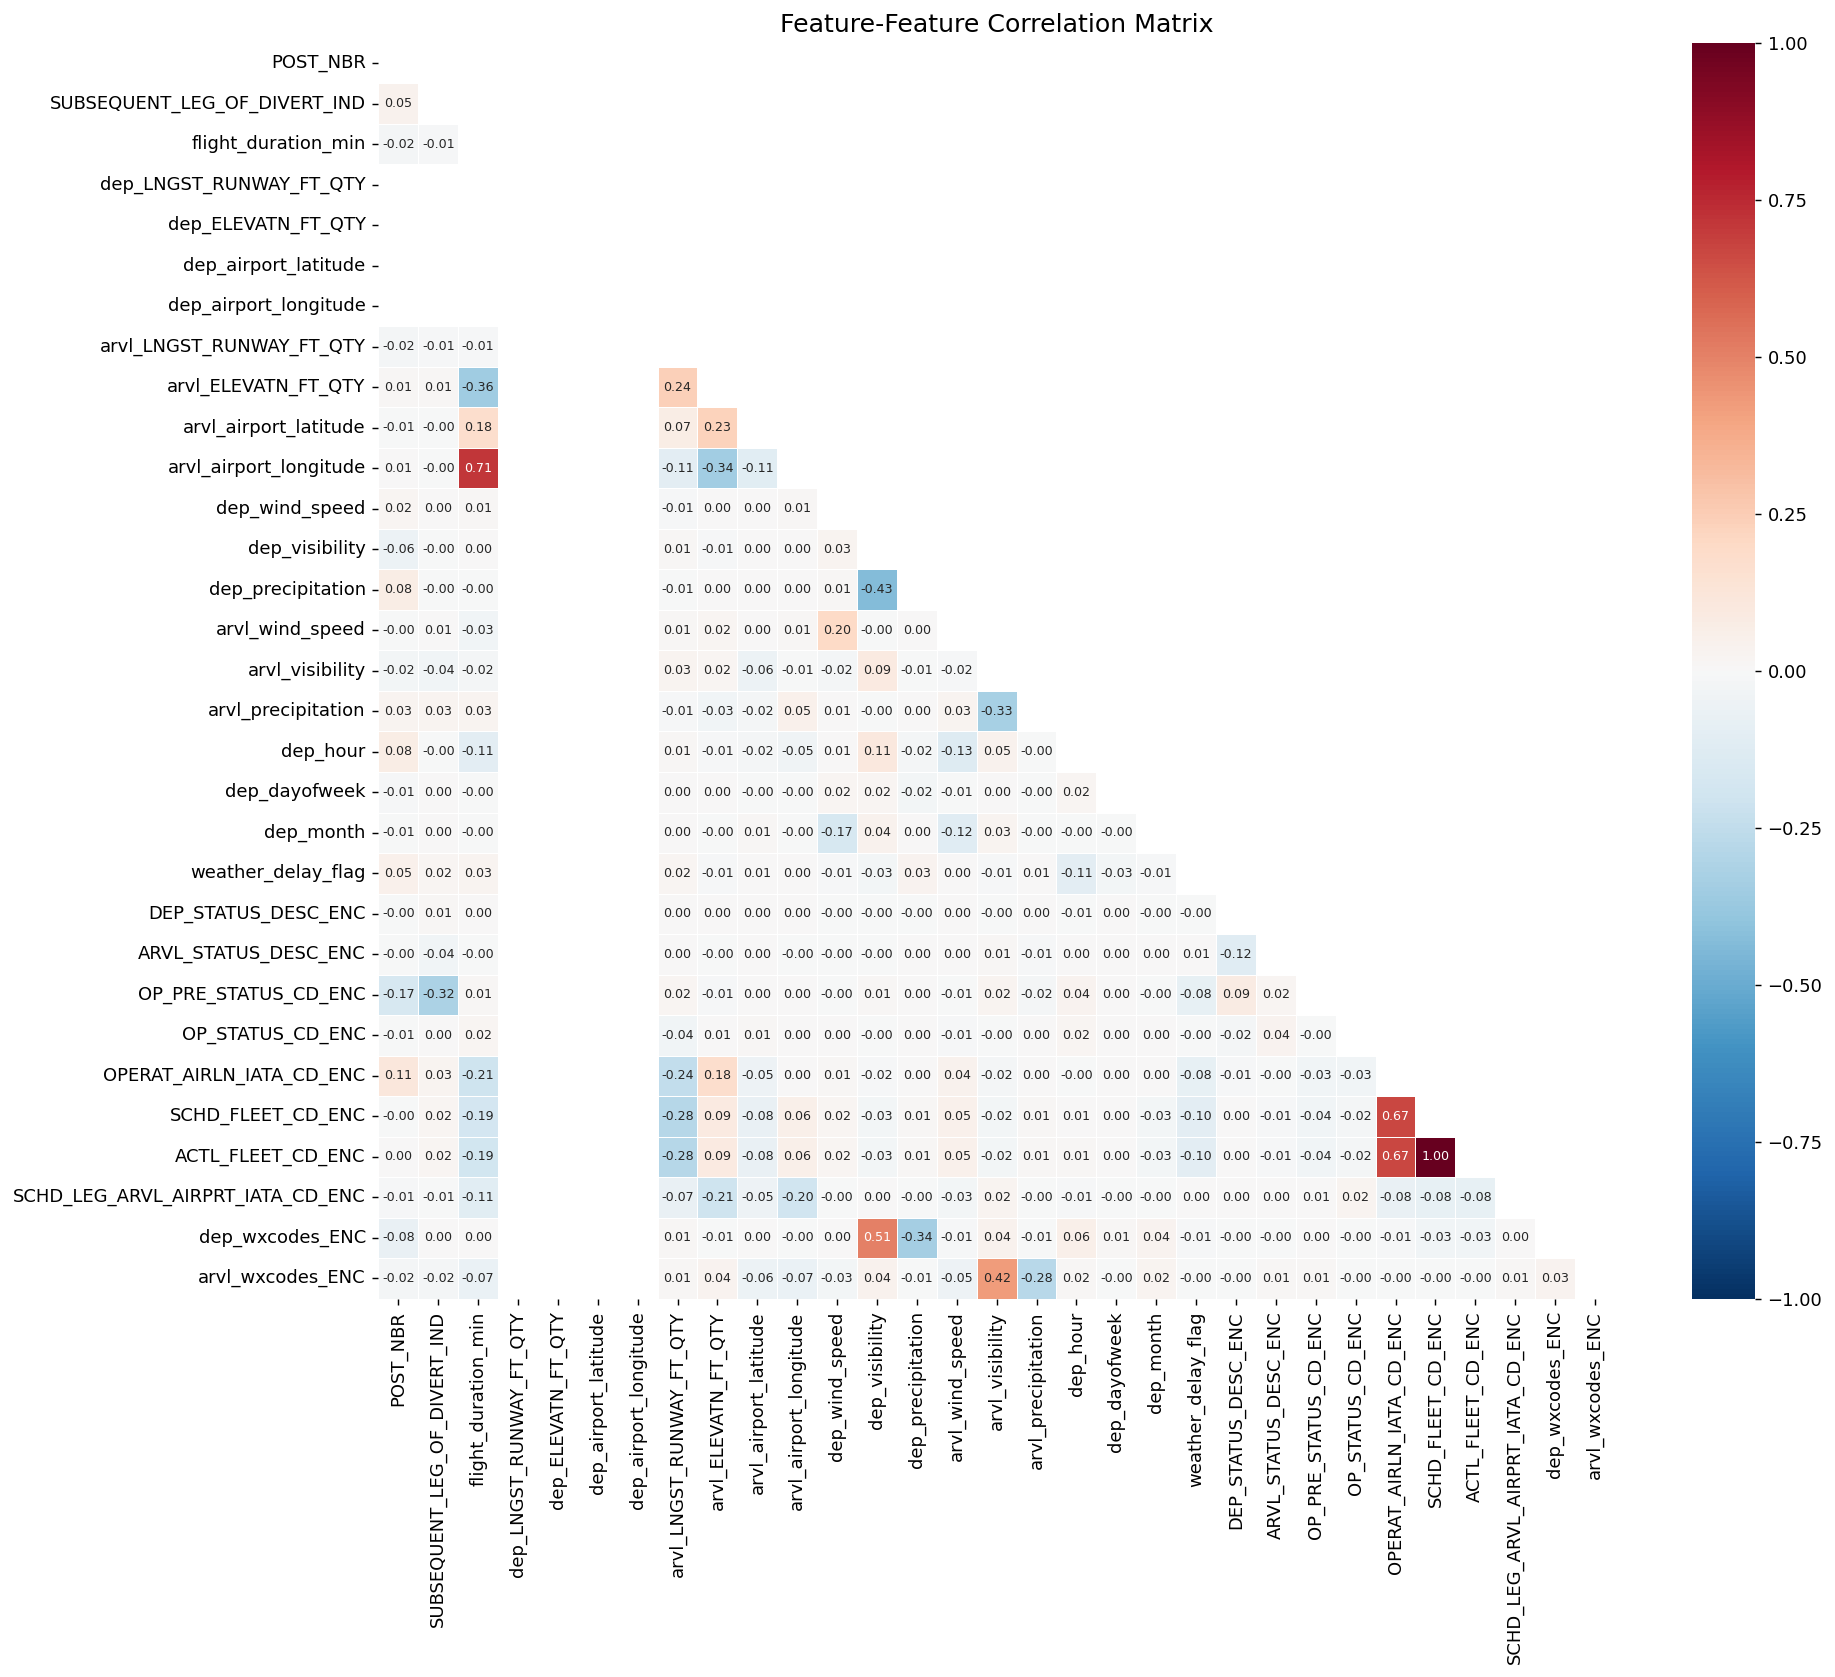

In [10]:
# ── Full feature-feature correlation heatmap ─────────────────────────────────
feature_cols = [c for c in df.columns if c not in targets]
corr_feat = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(15, 13))
mask = np.triu(np.ones_like(corr_feat, dtype=bool))
sns.heatmap(
    corr_feat, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Feature-Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('eda_mod_feature_corr_matrix.png', bbox_inches='tight')
plt.show()

In [11]:
# ── Flag high-correlation feature pairs (|r| > 0.7) ─────────────────────────
high_corr_pairs = []
for i in range(len(corr_feat.columns)):
    for j in range(i+1, len(corr_feat.columns)):
        r = corr_feat.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append({
                'Feature 1': corr_feat.columns[i],
                'Feature 2': corr_feat.columns[j],
                'Correlation': round(r, 3)
            })

hc_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
if len(hc_df) > 0:
    print(f'{len(hc_df)} feature pairs with |r| > 0.7 (potential multicollinearity):')
    display(hc_df)
else:
    print('No feature pairs with |r| > 0.7 — no multicollinearity concerns.')

2 feature pairs with |r| > 0.7 (potential multicollinearity):


,Feature 1,Feature 2,Correlation
1,SCHD_FLEET_CD_ENC,ACTL_FLEET_CD_ENC,0.998
0,flight_duration_min,arvl_airport_longitude,0.713


---
## 6. Feature Distributions Broken Down by Class

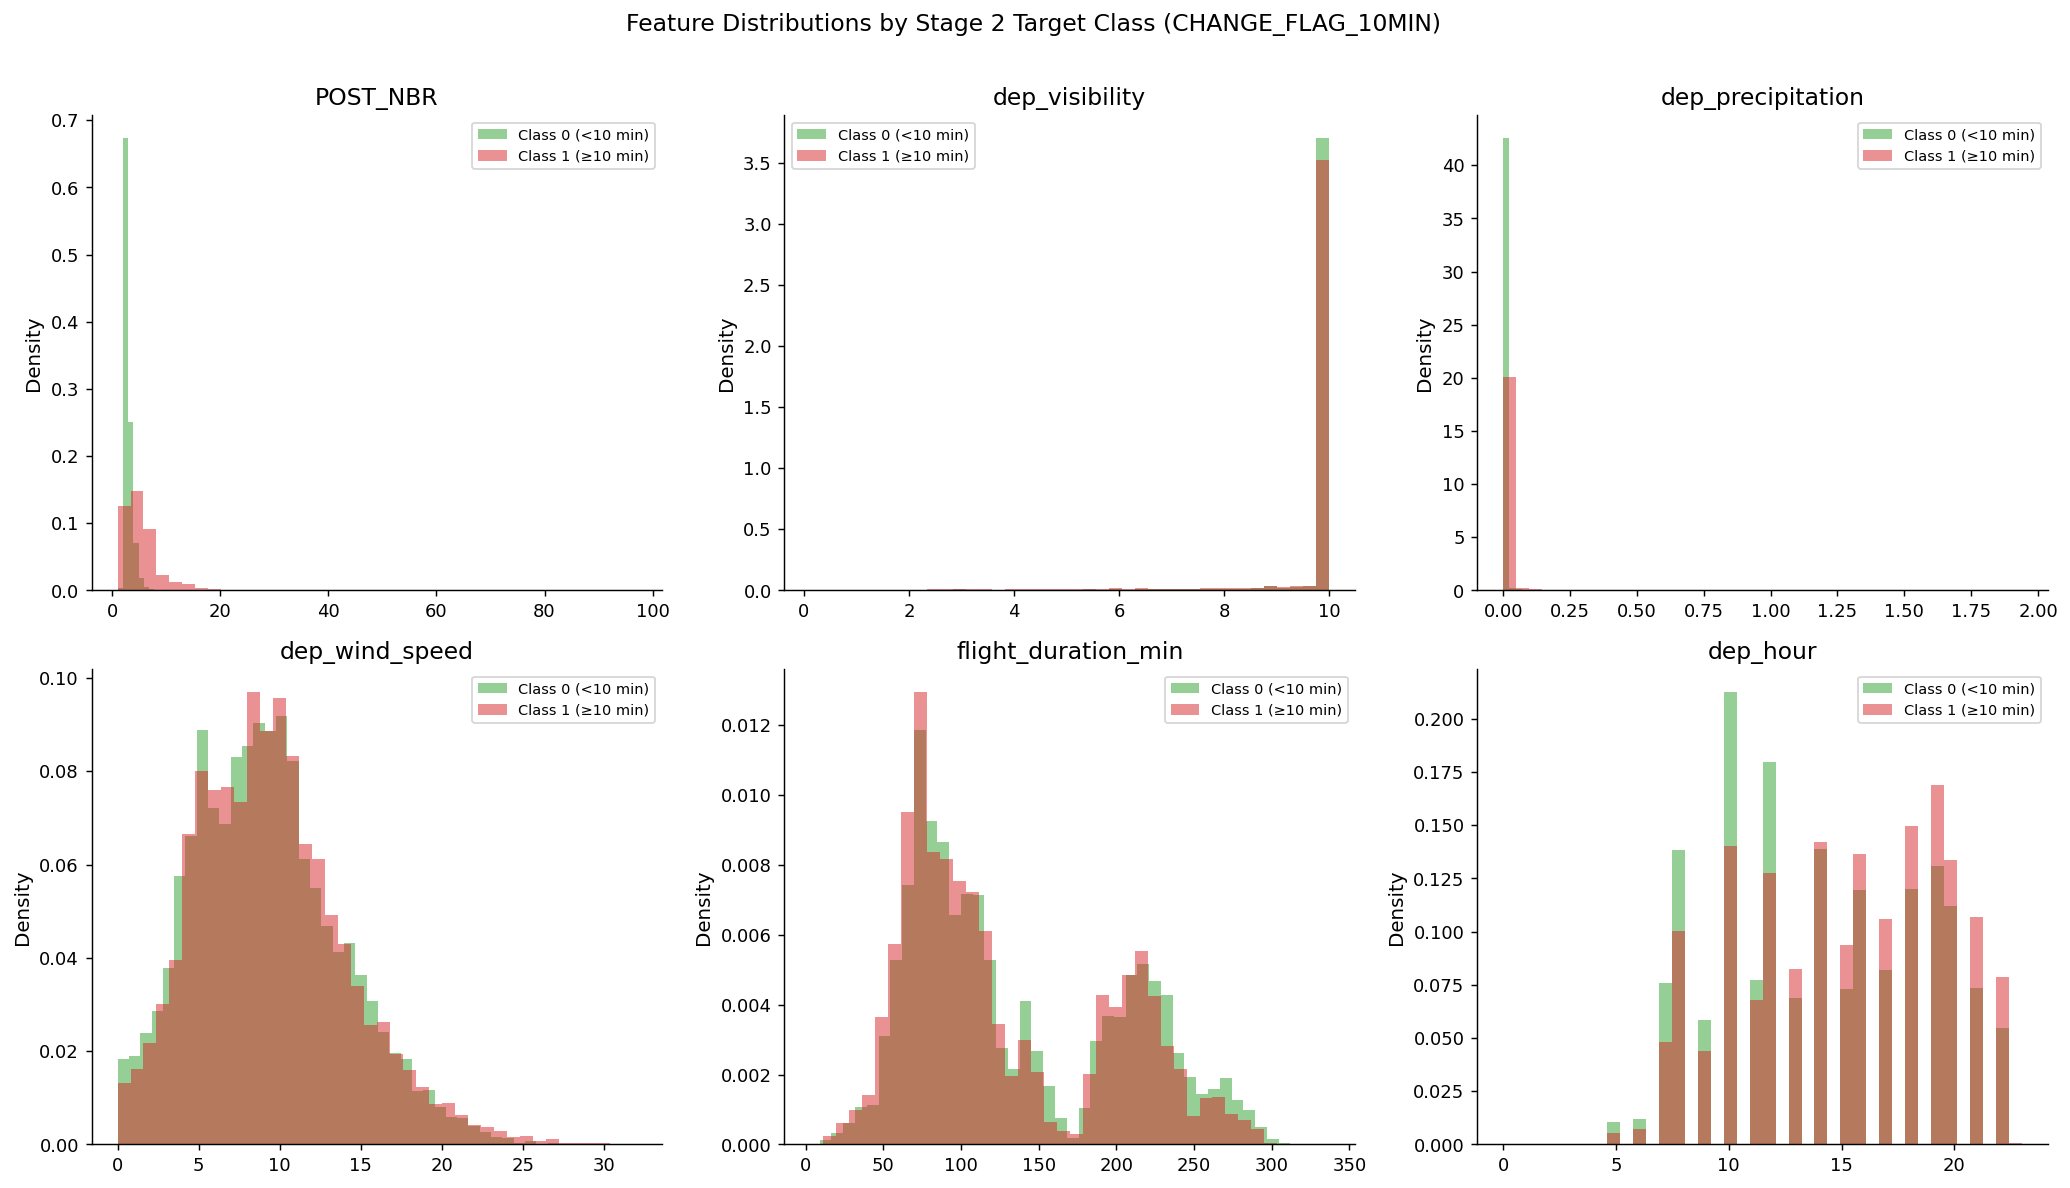

In [12]:
# ── Top continuous features split by CHANGE_FLAG_10MIN ───────────────────────
top_feats = ['POST_NBR', 'dep_visibility', 'dep_precipitation',
             'dep_wind_speed', 'flight_duration_min', 'dep_hour']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), top_feats):
    for cls, color, label in [(0, GREEN, 'Class 0 (<10 min)'), (1, RED, 'Class 1 (≥10 min)')]:
        subset = df[df['CHANGE_FLAG_10MIN'] == cls][col]
        ax.hist(subset, bins=40, color=color, alpha=0.5, density=True, label=label)
    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Stage 2 Target Class (CHANGE_FLAG_10MIN)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_mod_feat_by_class.png', bbox_inches='tight')
plt.show()

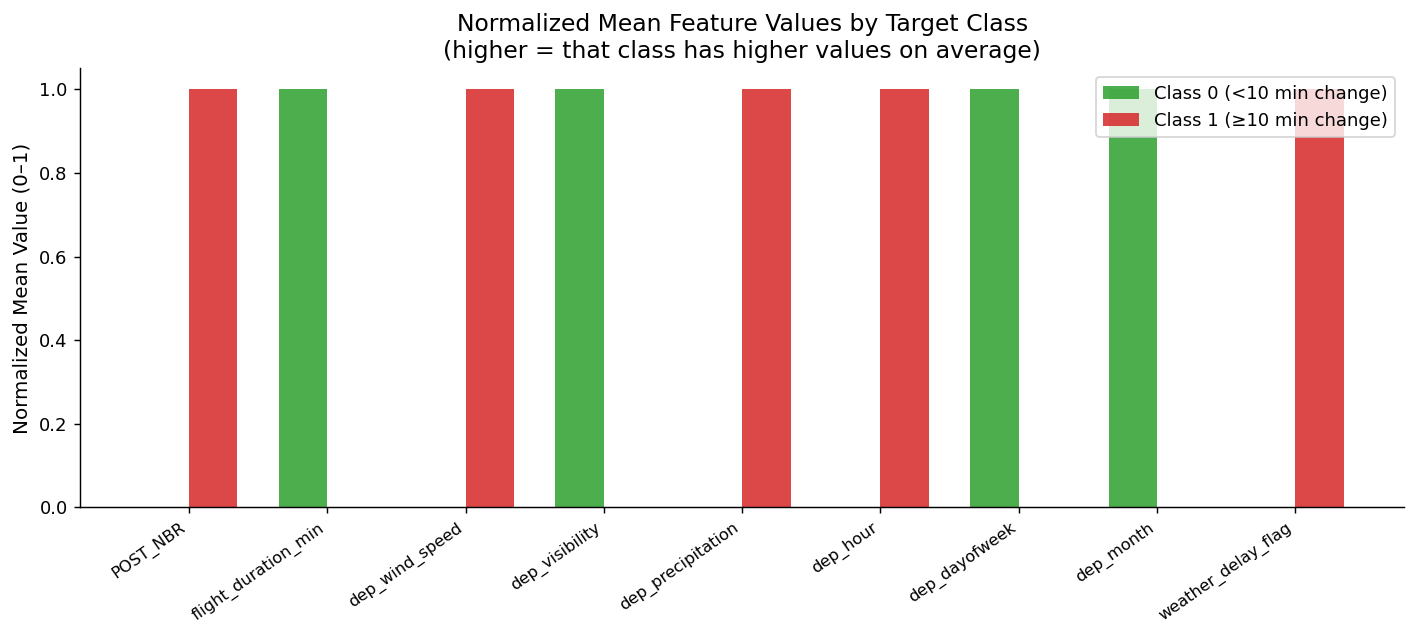

In [13]:
# ── Mean feature values by class (normalized) ────────────────────────────────
cont_feats = ['POST_NBR','flight_duration_min','dep_wind_speed',
              'dep_visibility','dep_precipitation','dep_hour',
              'dep_dayofweek','dep_month','weather_delay_flag']

class_means = df.groupby('CHANGE_FLAG_10MIN')[cont_feats].mean()
class_means_norm = (class_means - class_means.min()) / (class_means.max() - class_means.min())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cont_feats))
w = 0.35
ax.bar(x - w/2, class_means_norm.loc[0], width=w, color=GREEN, label='Class 0 (<10 min change)', alpha=0.85)
ax.bar(x + w/2, class_means_norm.loc[1], width=w, color=RED,   label='Class 1 (≥10 min change)', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cont_feats, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Normalized Mean Value (0–1)')
ax.set_title('Normalized Mean Feature Values by Target Class\n(higher = that class has higher values on average)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_mod_class_means.png', bbox_inches='tight')
plt.show()

---
## 7. Outlier Check on Final Features

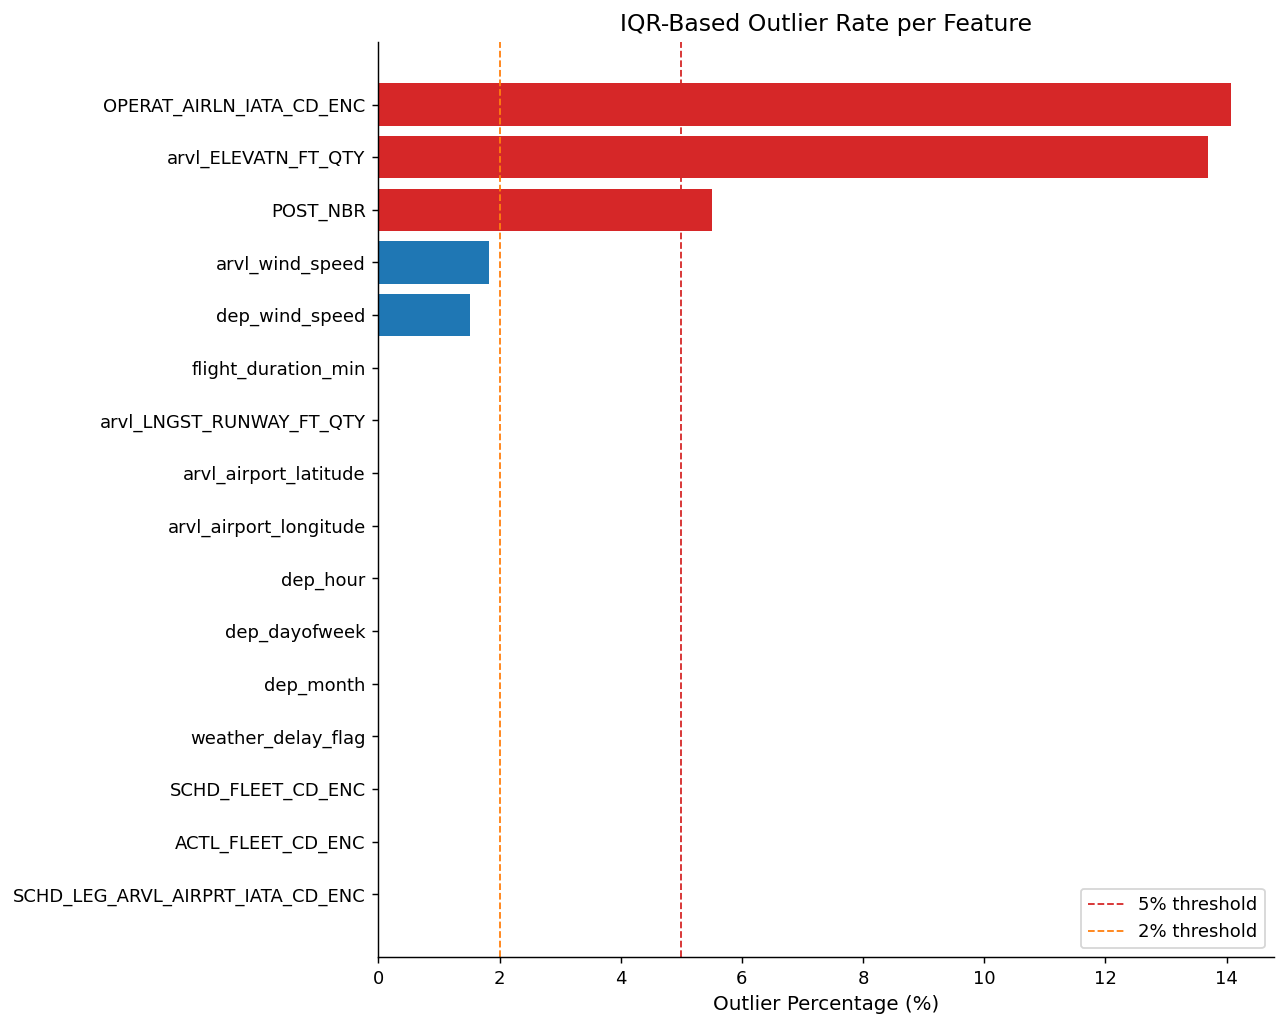

,Feature,Outliers (IQR),Outlier %
12,OPERAT_AIRLN_IATA_CD_ENC,29811,14.08
3,arvl_ELEVATN_FT_QTY,28993,13.69
0,POST_NBR,11670,5.51
7,arvl_wind_speed,3845,1.82
6,dep_wind_speed,3189,1.51
1,flight_duration_min,0,0.00
2,arvl_LNGST_RUNWAY_FT_QTY,0,0.00
4,arvl_airport_latitude,0,0.00
5,arvl_airport_longitude,0,0.00
8,dep_hour,0,0.00


In [14]:
# ── IQR-based outlier count per feature ──────────────────────────────────────
outlier_rows = []
for col in feature_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    outlier_rows.append({'Feature': col, 'Outliers (IQR)': n_out,
                         'Outlier %': round(n_out/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_rows).sort_values('Outlier %', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_out = [RED if v > 5 else ORANGE if v > 2 else BLUE for v in outlier_df['Outlier %']]
ax.barh(outlier_df['Feature'][::-1], outlier_df['Outlier %'][::-1], color=colors_out[::-1])
ax.axvline(5, color=RED,    linestyle='--', lw=1, label='5% threshold')
ax.axvline(2, color=ORANGE, linestyle='--', lw=1, label='2% threshold')
ax.set_xlabel('Outlier Percentage (%)')
ax.set_title('IQR-Based Outlier Rate per Feature')
ax.legend()
plt.tight_layout()
plt.savefig('eda_mod_outliers.png', bbox_inches='tight')
plt.show()

display(outlier_df.head(10))

---
## 8. Regression Target Skewness & Log-Transform Check

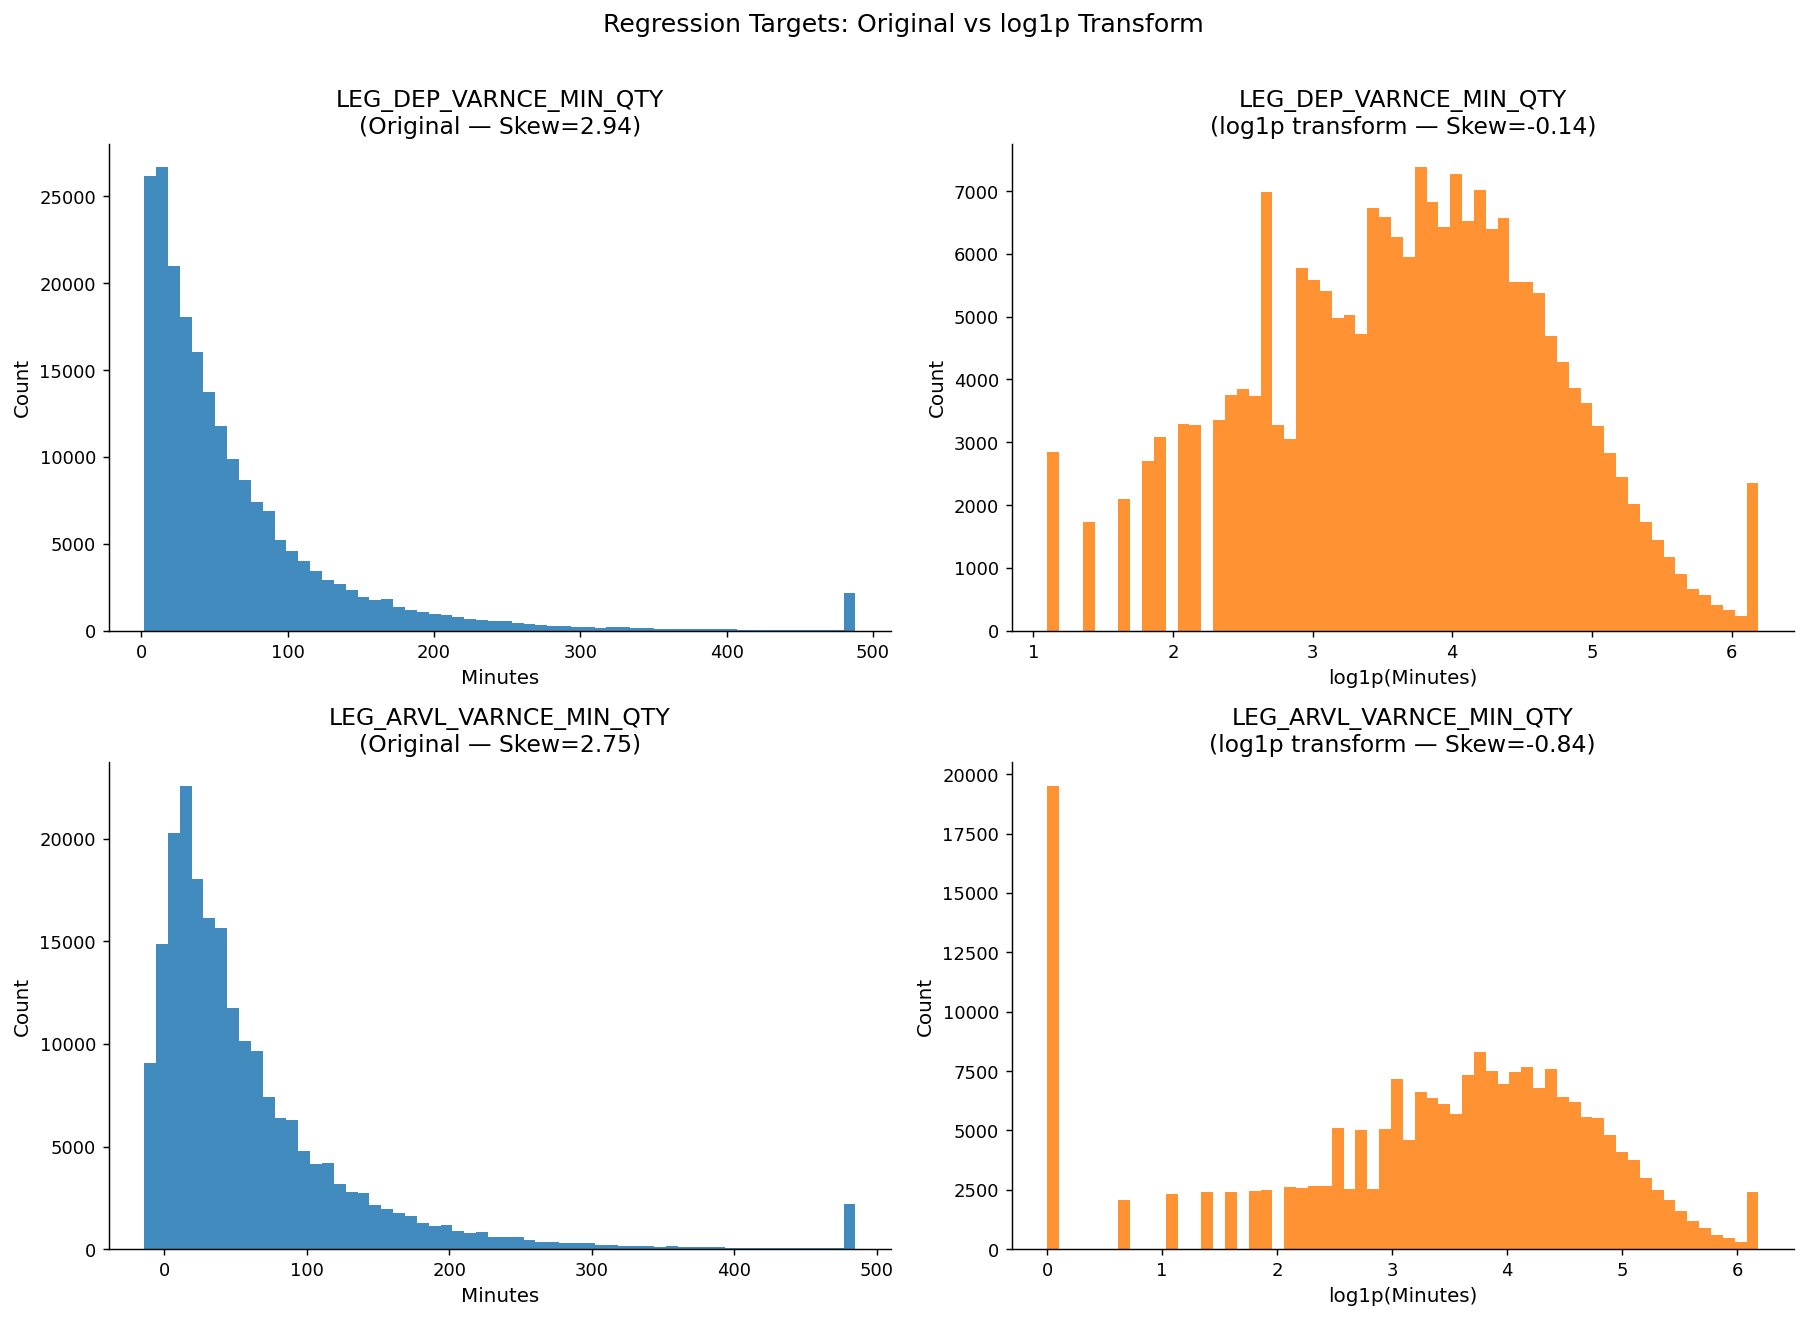

In [15]:
from scipy.stats import skew

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['LEG_DEP_VARNCE_MIN_QTY', 'LEG_ARVL_VARNCE_MIN_QTY']):
    original = df[col]
    log_transformed = np.log1p(original.clip(lower=0))

    axes[i][0].hist(original, bins=60, color=BLUE, edgecolor='none', alpha=0.85)
    axes[i][0].set_title(f'{col}\n(Original — Skew={skew(original):.2f})')
    axes[i][0].set_xlabel('Minutes')
    axes[i][0].set_ylabel('Count')

    axes[i][1].hist(log_transformed, bins=60, color=ORANGE, edgecolor='none', alpha=0.85)
    axes[i][1].set_title(f'{col}\n(log1p transform — Skew={skew(log_transformed):.2f})')
    axes[i][1].set_xlabel('log1p(Minutes)')
    axes[i][1].set_ylabel('Count')

plt.suptitle('Regression Targets: Original vs log1p Transform', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_mod_log_transform.png', bbox_inches='tight')
plt.show()

---
## 9. Pre-Modeling Checklist Summary

In [16]:
stage1_ratio = df['1MINCHANGE_FLAG_'].value_counts()[1] / df['1MINCHANGE_FLAG_'].value_counts()[0]
stage2_ratio = df['CHANGE_FLAG_10MIN'].value_counts()[1] / df['CHANGE_FLAG_10MIN'].value_counts()[0]
dep_skew     = skew(df['LEG_DEP_VARNCE_MIN_QTY'])

checklist = [
    ('Missing values',           'PASS',   '0 missing values across all 35 columns'),
    ('All numeric types',        'PASS',   'All columns are float64 or int64 — no encoding needed'),
    ('Stage 1 class balance',    'WARN',   f'Ratio {stage1_ratio:.0f}:1 → use class_weight="balanced" or SMOTE'),
    ('Stage 2 class balance',    'WARN',   f'Ratio {stage2_ratio:.1f}:1 → use class_weight="balanced"'),
    ('Regression target skew',   'WARN',   f'Dep skew={dep_skew:.2f} → consider log1p transform for linear models'),
    ('Feature scaling needed',   'WARN',   'Lat/long, runway (large ranges) need StandardScaler for LR/SVM'),
    ('Multicollinearity',        'CHECK',  'Run high-corr check above — dep/arvl pairs may be correlated'),
    ('Target leakage',           'CHECK',  'LEG_DEP/ARVL_VARNCE are regression targets — exclude from classification features'),
    ('Row count for modeling',   'PASS',   f'211,800 rows — sufficient for train/val/test split (80/10/10)'),
    ('Feature count',            'PASS',   f'31 features — manageable, no dimensionality reduction needed'),
]

check_df = pd.DataFrame(checklist, columns=['Check', 'Status', 'Notes'])

def color_status(val):
    if val == 'PASS':  return 'background-color: #c8e6c9'
    if val == 'WARN':  return 'background-color: #fff9c4'
    if val == 'CHECK': return 'background-color: #ffe0b2'
    return ''

display(check_df.style.applymap(color_status, subset=['Status']))

,Check,Status,Notes
0,Missing values,PASS,0 missing values across all 35 columns
1,All numeric types,PASS,All columns are float64 or int64 — no encoding needed
2,Stage 1 class balance,WARN,"Ratio 98:1 → use class_weight=""balanced"" or SMOTE"
3,Stage 2 class balance,WARN,"Ratio 4.1:1 → use class_weight=""balanced"""
4,Regression target skew,WARN,Dep skew=2.94 → consider log1p transform for linear models
5,Feature scaling needed,WARN,"Lat/long, runway (large ranges) need StandardScaler for LR/SVM"
6,Multicollinearity,CHECK,Run high-corr check above — dep/arvl pairs may be correlated
7,Target leakage,CHECK,LEG_DEP/ARVL_VARNCE are regression targets — exclude from classification features
8,Row count for modeling,PASS,"211,800 rows — sufficient for train/val/test split (80/10/10)"
9,Feature count,PASS,"31 features — manageable, no dimensionality reduction needed"


---
## 10. Modeling Recommendations

Based on this EDA, the following decisions are recommended before training:

### Classification (Stage 1 & Stage 2)
| Issue | Recommendation |
|---|---|
| Stage 1 extreme imbalance (98:1) | Use `class_weight='balanced'` in all classifiers; evaluate with F1 / AUC, NOT accuracy |
| Stage 2 moderate imbalance (4:1) | Use `class_weight='balanced'`; evaluate with F1 macro / AUC |
| Feature scales vary widely | Use `StandardScaler` for logistic regression / SVM; tree models don't need it |
| `LEG_DEP/ARVL_VARNCE` in dataset | **Must exclude from classification features** — they are the regression targets, not predictors |

### Regression (Variance Prediction)
| Issue | Recommendation |
|---|---|
| Right-skewed targets | Apply `np.log1p()` transform before training linear models; inverse-transform predictions |
| Tree models | Skew is less of a concern for Random Forest / XGBoost — test both |
| High POST_NBR correlation | Verify this isn't leakage — it reflects how many updates have already been posted |

### Train / Validation / Test Split
- Use **time-based split** (not random) — e.g., train on 2021–2023, validate on 2024, test on 2025  
- Random splitting would leak future flight patterns into training data